In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_approval_data.csv")
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [70]:
df["Education_Level"].unique()

array(['Not Graduate', 'Graduate'], dtype=object)

* Data cleaning

In [3]:
df = df.dropna(subset=["Loan_Approved"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        902 non-null    float64
 1   Applicant_Income    902 non-null    float64
 2   Coapplicant_Income  902 non-null    float64
 3   Employment_Status   906 non-null    object 
 4   Age                 902 non-null    float64
 5   Marital_Status      902 non-null    object 
 6   Dependents          903 non-null    float64
 7   Credit_Score        902 non-null    float64
 8   Existing_Loans      901 non-null    float64
 9   DTI_Ratio           903 non-null    float64
 10  Savings             901 non-null    float64
 11  Collateral_Value    901 non-null    float64
 12  Loan_Amount         903 non-null    float64
 13  Loan_Term           902 non-null    float64
 14  Loan_Purpose        902 non-null    object 
 15  Property_Area       901 non-null    object 
 16  Education_Lev

In [5]:
categorical_col = df.select_dtypes(include=["object"]).columns
Numerical_col = df.select_dtypes(include=["float64"]).columns

In [6]:
from sklearn.impute import SimpleImputer

In [7]:
num_imp = SimpleImputer(strategy="mean")
df[Numerical_col] = num_imp.fit_transform(df[Numerical_col])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_col] = cat_imp.fit_transform(df[categorical_col])


C:\Users\prita\AppData\Local\Temp\ipykernel_2464\4059591411.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[Numerical_col] = num_imp.fit_transform(df[Numerical_col])
C:\Users\prita\AppData\Local\Temp\ipykernel_2464\4059591411.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical_col] = cat_imp.fit_transform(df[categorical_col])


* EDA 

([<matplotlib.patches.Wedge at 0x2b7a01611b0>,
 [Text(-0.6077203342081817, 0.91688385054482, 'No'),
  Text(0.6077206329668295, -0.9168836525243518, 'Yes')],
 [Text(-0.33148381865900817, 0.5001184639335382, '68.6%'),
  Text(0.3314839816182706, -0.5001183559223736, '31.4%')])

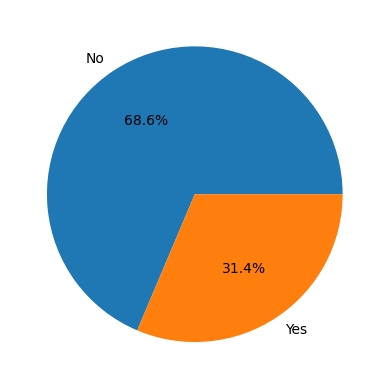

In [8]:
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")

In [9]:
print(categorical_col)
print(Numerical_col)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


<Axes: xlabel='Loan_Amount', ylabel='Property_Area'>

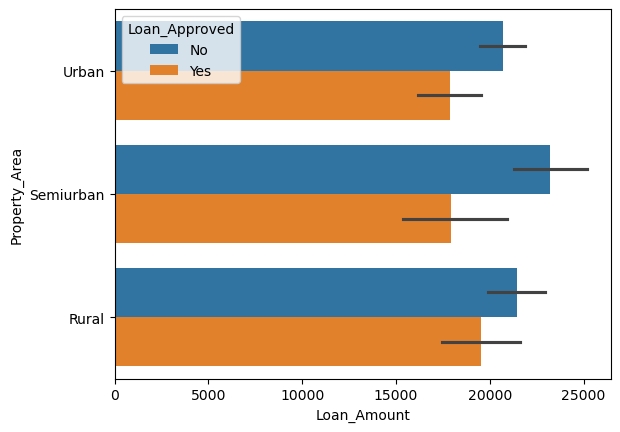

In [10]:
sns.barplot(
    data=df,
    x = df["Loan_Amount"],
    y = df["Property_Area"],
    hue=df["Loan_Approved"]
)

<Axes: xlabel='Applicant_Income', ylabel='Loan_Approved'>

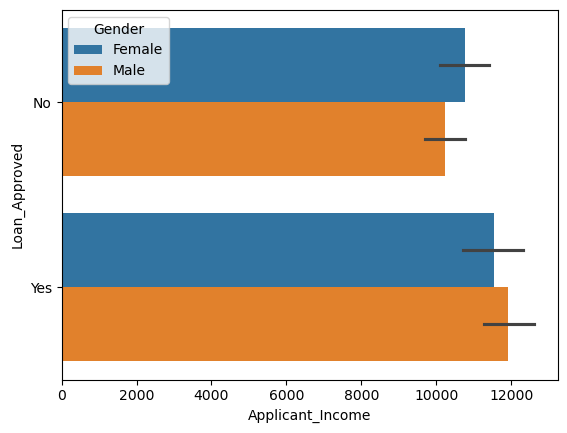

In [11]:
sns.barplot(
    data = df,
    x = df["Applicant_Income"],
    y = df["Loan_Approved"],
    hue=df["Gender"]
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

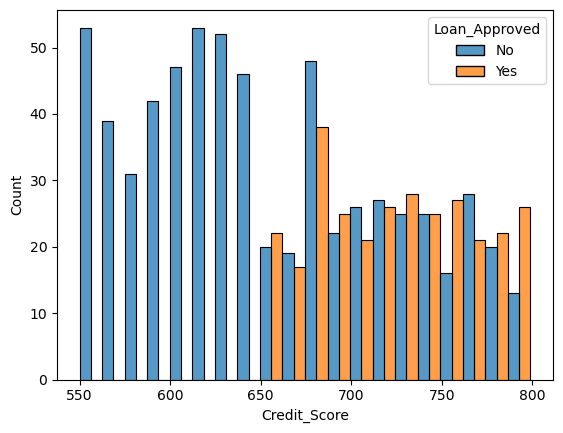

In [12]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

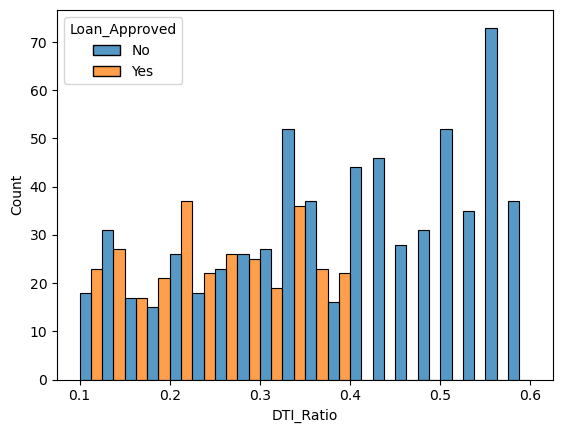

In [13]:
sns.histplot(
    data = df,
    x = "DTI_Ratio",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Employment_Status', ylabel='Count'>

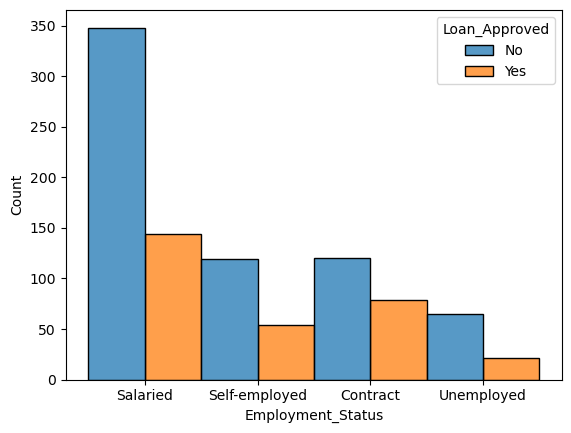

In [14]:
sns.histplot(
    data = df,
    x = "Employment_Status",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Employer_Category', ylabel='Count'>

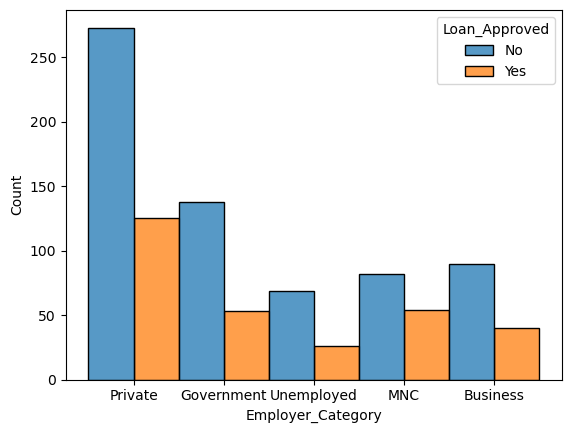

In [15]:
sns.histplot(
    data = df,
    x = "Employer_Category",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Employment_Status', ylabel='Employer_Category'>

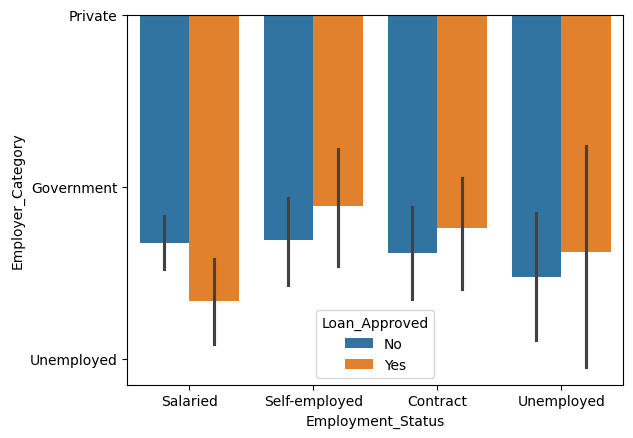

In [16]:
sns.barplot(
    data = df,
    x = df["Employment_Status"],
    y = df["Employer_Category"],
    hue=df["Loan_Approved"]
)

* feature encoding

In [17]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [18]:
df_encod = df.copy()

In [19]:
le_col = ['Education_Level', 'Loan_Approved', 'Marital_Status']
ohe_col = ['Employment_Status', 'Loan_Purpose', 'Property_Area', 'Gender', 'Employer_Category']

In [20]:
le = LabelEncoder()
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

In [21]:
for col in le_col:
    df_encod[col] = le.fit_transform(df_encod[col])

In [22]:
encoded = ohe.fit_transform(df_encod[ohe_col])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(ohe_col),
    index=df_encod.index
)

In [23]:
# Merge
df_encod = df_encod.drop(columns=ohe_col)
df_final = pd.concat([df_encod, encoded_df], axis=1)

In [24]:
df_final

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.00000,1387.0,51.0,0,0.0,637.0,4.0,0.53,19403.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.00000,2679.0,46.0,0,3.0,621.0,2.0,0.30,2580.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.00000,2106.0,25.0,1,2.0,674.0,4.0,0.20,13844.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.00000,8173.0,40.0,0,2.0,579.0,3.0,0.31,9553.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.00000,4223.0,31.0,1,2.0,721.0,1.0,0.29,9386.000000,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10847.01663,9092.0,58.0,0,0.0,557.0,0.0,0.59,5370.000000,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,997.0,3279.00000,6356.0,58.0,0,1.0,646.0,3.0,0.19,9966.298557,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,998.0,15192.00000,8433.0,48.0,1,1.0,666.0,1.0,0.40,8581.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,999.0,9083.00000,7380.0,50.0,1,1.0,748.0,3.0,0.31,13491.000000,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [25]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     950 non-null    float64
 1   Applicant_Income                 950 non-null    float64
 2   Coapplicant_Income               950 non-null    float64
 3   Age                              950 non-null    float64
 4   Marital_Status                   950 non-null    int64  
 5   Dependents                       950 non-null    float64
 6   Credit_Score                     950 non-null    float64
 7   Existing_Loans                   950 non-null    float64
 8   DTI_Ratio                        950 non-null    float64
 9   Savings                          950 non-null    float64
 10  Collateral_Value                 950 non-null    float64
 11  Loan_Amount                      950 non-null    float64
 12  Loan_Term                  

* Checking relation

In [26]:
num_col = df_final.select_dtypes('number')
corr_matrix = num_col.corr()

In [27]:
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_ID,1.000000,0.009590,0.032424,0.011736,-0.002464,0.020150,-0.039263,0.030941,0.004955,0.026515,...,-0.006800,-0.048407,0.026476,1.542300e-02,-0.028162,0.025607,0.010713,-0.088676,0.027185,3.931158e-02
Applicant_Income,0.009590,1.000000,0.003860,-0.018732,0.017027,-0.025363,-0.013122,-0.012284,0.011447,-0.037440,...,0.029460,0.069358,-0.020608,4.980275e-03,-0.041390,-0.028595,-0.033947,0.085052,-0.021514,-1.775526e-02
Coapplicant_Income,0.032424,0.003860,1.000000,0.013481,-0.007461,-0.042312,0.061138,0.024071,0.069662,-0.010308,...,0.034726,0.003986,0.072649,-9.548065e-03,0.030707,-0.011726,-0.001185,0.026395,0.009685,-4.592357e-02
Age,0.011736,-0.018732,0.013481,1.000000,0.021594,-0.009482,0.004590,0.022606,0.012720,0.009305,...,0.003039,0.033365,0.026234,-6.583003e-04,-0.023484,0.044326,-0.052209,0.019099,-0.022902,7.493626e-02
Marital_Status,-0.002464,0.017027,-0.007461,0.021594,1.000000,-0.012049,0.047439,0.021304,-0.022077,-0.017784,...,-0.014948,0.014203,-0.061036,5.355586e-02,-0.059499,0.030395,-0.029423,0.025427,-0.010482,2.570318e-02
Dependents,0.020150,-0.025363,-0.042312,-0.009482,-0.012049,1.000000,-0.013184,-0.027879,0.000555,-0.005310,...,-0.054971,0.031684,0.000139,-2.731582e-02,0.018414,0.009484,-0.001488,-0.034960,0.034212,-5.397495e-02
Credit_Score,-0.039263,-0.013122,0.061138,0.004590,0.047439,-0.013184,1.000000,-0.010834,-0.000699,-0.068957,...,0.004186,-0.000852,0.019909,-1.639268e-02,0.005349,-0.031730,-0.015739,0.061825,0.012565,-3.999288e-02
Existing_Loans,0.030941,-0.012284,0.024071,0.022606,0.021304,-0.027879,-0.010834,1.000000,0.047610,0.029487,...,0.000750,-0.000529,0.016120,-5.321658e-02,0.024462,-0.031012,-0.001065,0.023022,-0.025875,4.214994e-02
DTI_Ratio,0.004955,0.011447,0.069662,0.012720,-0.022077,0.000555,-0.000699,0.047610,1.000000,0.020290,...,0.042972,-0.004589,-0.041852,4.658956e-02,0.000157,0.016110,-0.004119,0.006217,-0.011938,3.524155e-02
Savings,0.026515,-0.037440,-0.010308,0.009305,-0.017784,-0.005310,-0.068957,0.029487,0.020290,1.000000,...,0.026258,-0.010026,-0.016783,1.628893e-02,0.006835,-0.002839,-0.020608,-0.011170,-0.019105,2.694361e-02


In [28]:
num_col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.476911
Applicant_Income                   0.125010
Employer_Category_MNC              0.073448
Marital_Status                     0.037586
Loan_Purpose_Personal              0.035519
Collateral_Value                   0.027350
Property_Area_Urban                0.025731
Coapplicant_Income                 0.009127
Loan_Purpose_Home                  0.003108
Employer_Category_Private          0.000707
Employment_Status_Self-employed   -0.001572
Applicant_ID                      -0.005382
Loan_Purpose_Education            -0.011940
Property_Area_Semiurban           -0.014259
Dependents                        -0.016199
Savings                           -0.016857
Age                               -0.027393
Employer_Category_Unemployed      -0.028736
Existing_Loans                    -0.035384
Employer_Category_Government      -0.039135
Employment_Status_Salaried        -0.046912
Employment_Status_Unemployed    

* Feature Scaling

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [30]:
X = df_final.drop(columns=(["Loan_Approved", "Applicant_ID"]))
y = df_final["Loan_Approved"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
scaler = StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Model training

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

In [35]:
# LogisticRegression model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

In [36]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.8727272727272727
recall_score :  0.7868852459016393
f1_score :  0.8275862068965517
accuracy_score :  0.8947368421052632
confusion_matrix : 
 [[122   7]
 [ 13  48]]


In [37]:
# using pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("lr", LogisticRegression())
])

param_grid_lr = {
    "lr__C": [0.1, 0.2, 0.3, 0.4, 0.5]
}

lr_model_cv = GridSearchCV(
    pipeline,
    param_grid=param_grid_lr,
    cv = 5,
    scoring="precision"
)

lr_model_cv.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'lr__C': [0.1, 0.2, ...]}"
,scoring,'precision'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [38]:
y_pred = lr_model_cv.predict(X_test)

In [39]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.8888888888888888
recall_score :  0.7868852459016393
f1_score :  0.8347826086956521
accuracy_score :  0.9
confusion_matrix : 
 [[123   6]
 [ 13  48]]


In [40]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

In [41]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.7333333333333333
recall_score :  0.5409836065573771
f1_score :  0.6226415094339622
accuracy_score :  0.7894736842105263
confusion_matrix : 
 [[117  12]
 [ 28  33]]


In [42]:
# With Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "knn__n_neighbors" : [3, 5, 7, 9, 11, 13, 15, 17, 19]
}

knn_model_cv = GridSearchCV(
    pipeline,
    param_grid=param_grid_knn,
    cv = 5,
    scoring="precision"
)

knn_model_cv.fit(X_train, y_train)

y_pred = knn_model_cv.predict(X_test)

In [43]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.9411764705882353
recall_score :  0.5245901639344263
f1_score :  0.6736842105263158
accuracy_score :  0.8368421052631579
confusion_matrix : 
 [[127   2]
 [ 29  32]]


In [44]:
res = pd.DataFrame(knn_model_cv.cv_results_)

print(knn_model_cv.best_params_)

{'knn__n_neighbors': 19}


In [45]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

In [46]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.8979591836734694
recall_score :  0.7213114754098361
f1_score :  0.8
accuracy_score :  0.8842105263157894
confusion_matrix : 
 [[124   5]
 [ 17  44]]


In [47]:
# using cross-validation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param = {
    "var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
}

nb_model_cv = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param,
    cv=5,
    scoring="precision"
)

nb_model_cv.fit(X_train, y_train)

y_pred = nb_model_cv.predict(X_test)

In [48]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.8979591836734694
recall_score :  0.7213114754098361
f1_score :  0.8
accuracy_score :  0.8842105263157894
confusion_matrix : 
 [[124   5]
 [ 17  44]]


In [49]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=701,
    max_depth=4,
    oob_score=True,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [50]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.9152542372881356
recall_score :  0.8852459016393442
f1_score :  0.9
accuracy_score :  0.9368421052631579
confusion_matrix : 
 [[124   5]
 [  7  54]]


In [51]:
print("OOB score: ", rf_model.oob_score_ * 100, "%")

OOB score:  93.02631578947368 %


In [ ]:
# With cross validation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param = {
    "n_estimators" : [101, 201, 301, 401, 501, 421, 221, 321, 123, 341, 701]
}

rf_model_cv = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param,
    cv=5,
    scoring="precision",
    n_jobs = -1 # Use ALL available CPU cores
)

rf_model_cv.fit(X_train,y_train)

y_pred = rf_model_cv.predict(X_test)

In [53]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))
print("OOB score: ", rf_model.oob_score_ * 100, "%")

Precision :  0.9076923076923077
recall_score :  0.9672131147540983
f1_score :  0.9365079365079365
accuracy_score :  0.9578947368421052
confusion_matrix : 
 [[123   6]
 [  2  59]]
OOB score:  93.02631578947368 %


In [54]:
# SVC

from sklearn.svm import SVC

svc_model = SVC()

svc_model.fit(X_train_scaled, y_train)

y_pred = svc_model.predict(X_test_scaled)

In [55]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.9387755102040817
recall_score :  0.7540983606557377
f1_score :  0.8363636363636363
accuracy_score :  0.9052631578947369
confusion_matrix : 
 [[126   3]
 [ 15  46]]


In [56]:
# with pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("svc", SVC())
])

param = {
    "svc__C": [0.1, 1, 10, 20, 30, 12, 45, 67, 45, 78, 54, 76, 98, 16, 18, 29, 39, 49,100],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

svc_model_cv = GridSearchCV(
    pipeline,
    param_grid=param,
    scoring="precision",
    cv = 5,
    n_jobs=-1
)

svc_model_cv.fit(X_train, y_train)

y_pred = svc_model_cv.predict(X_test)

In [57]:
print("Precision : ", precision_score(y_test, y_pred)) # main priority
print("recall_score : ", recall_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

Precision :  0.9387755102040817
recall_score :  0.7540983606557377
f1_score :  0.8363636363636363
accuracy_score :  0.9052631578947369
confusion_matrix : 
 [[126   3]
 [ 15  46]]


* Final (Best Model :- Random Forest)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

param = {
    "rf__n_estimators": [101, 201, 301, 401, 501, 421, 221, 321, 123, 341, 701]
}

rf_model_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param,
    cv=5,
    scoring="precision",
    n_jobs=-1
)

rf_model_cv.fit(X_train, y_train)

y_pred = rf_model_cv.predict(X_test)

In [60]:
import joblib

joblib.dump(rf_model_cv.best_estimator_, "rf_model.pkl")

['rf_model.pkl']